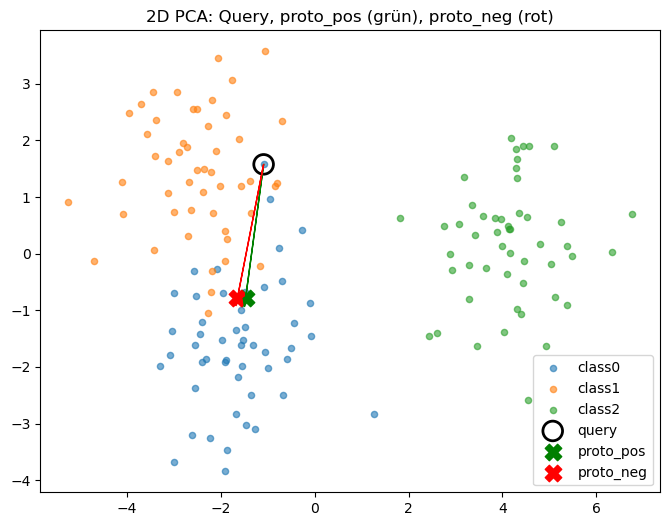

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch.nn.functional as F

# toy data: 3 classes in 32-d, 200 points
D = 32
N = 200
np.random.seed(9)
embs = np.vstack([
    np.random.randn(N//4, D) + np.array([i*3.0 if j==i else 0 for j in range(D)])
    for i in range(3)
])
labels = np.array([0]*(N//4) + [1]*(N//4) + [2]*(N//4))
# pad to N
embs = embs[:N]
labels = labels[:N]

# pick a query (index 5)
q_idx = 5
q = torch.tensor(embs[q_idx: q_idx+1], dtype=torch.float32)
db = torch.tensor(embs, dtype=torch.float32)
dbn = F.normalize(db, dim=1)
qn = F.normalize(q, dim=1)
sims = (dbn @ qn.t()).squeeze(1).numpy()

# compute proto_pos (soft over positives)
pos_mask = labels == labels[q_idx]
sims_pos = sims[pos_mask]
alphas_pos = np.exp(sims_pos / 0.05); alphas_pos /= alphas_pos.sum()
proto_pos = (alphas_pos[:,None] * dbn[pos_mask].numpy()).sum(axis=0)

# compute topk neg proto
neg_mask = ~pos_mask
sims_negs = sims[neg_mask]
k = min(50, sims_negs.size)
topk_idx_in_negs = np.argsort(sims_negs)[-k:]
chosen_idx = np.where(neg_mask)[0][topk_idx_in_negs]
topk_vals = sims[chosen_idx]
alphas_neg = np.exp(topk_vals / 0.05); alphas_neg /= alphas_neg.sum()
proto_neg = (alphas_neg[:,None] * dbn[chosen_idx].numpy()).sum(axis=0)

# 2D projection
pca = PCA(2)
proj = pca.fit_transform(embs)
qp = proj[q_idx]
pp = pca.transform(proto_pos.reshape(1,-1))[0]
pn = pca.transform(proto_neg.reshape(1,-1))[0]

plt.figure(figsize=(8,6))
for c in np.unique(labels):
    idx = labels==c
    plt.scatter(proj[idx,0], proj[idx,1], s=20, label=f"class{c}", alpha=0.6)
plt.scatter(qp[0], qp[1], s=200, facecolors='none', edgecolors='k', linewidths=2, label='query')
plt.scatter(pp[0], pp[1], s=140, marker='X', c='green', label='proto_pos')
plt.scatter(pn[0], pn[1], s=140, marker='X', c='red', label='proto_neg')
plt.arrow(qp[0], qp[1], pp[0]-qp[0], pp[1]-qp[1], color='green', head_width=0.1)
plt.arrow(qp[0], qp[1], pn[0]-qp[0], pn[1]-qp[1], color='red', head_width=0.1)
plt.legend(); plt.title("2D PCA: Query, proto_pos (grün), proto_neg (rot)")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Consistent Data for all plots ---
# A query embedding
query = np.array([3.5, 4.0])

# Embeddings of the same identity (positives)
positives = np.array([
    [2.0, 3.5],
    [2.5, 2.5],
    [1.5, 4.5]
])

# Embeddings of different identities (negatives)
negatives = np.array([
    [7.0, 7.0], # Easy negative (far away)
    [8.0, 5.5], # Easy negative (far away)
    [4.5, 5.0]  # Hard negative (confusingly close)
])

# --- Helper function for plotting the base points ---
def plot_base(ax, title):
    """Plots the basic scatter plot for each scenario."""
    ax.scatter(positives[:, 0], positives[:, 1], c='blue', marker='o', s=80, label='Positives (Friends)')
    ax.scatter(negatives[:, 0], negatives[:, 1], c='red', marker='s', s=80, label='Negatives (Foes)')
    ax.scatter(query[0], query[1], c='gold', marker='*', s=300, label='Query', edgecolors='black')
    ax.set_title(title, fontsize=14, pad=10)
    ax.legend()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)

In [ ]:
def plot_Similarity Score(ax):
    plot_base(ax, "Score 1: Simple Similarity\n'Find the Twin'")

    # Find the closest positive to the query
    distances = np.linalg.norm(positives - query, axis=1)
    closest_positive_idx = np.argmin(distances)
    closest_positive = positives[closest_positive_idx]

    # Visualize the focus: a single line of attraction
    ax.arrow(query[0], query[1],
             closest_positive[0] - query[0],
             closest_positive[1] - query[1],
             head_width=0.2, head_length=0.3, fc='green', ec='green', length_includes_head=True,
             linestyle='--', linewidth=2)

    ax.text(0.5, 0.05, "Focus: Pull query only towards its closest positive.\nIgnores all negatives and other positives.",
            transform=ax.transAxes, ha='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

In [9]:
def plot_knn_proxy_soft(ax):
    plot_base(ax, "Score 2: Soft k-NN Proxy\n'Join the Right Club'")

    # Visualize the "pull" from all positives
    for p in positives:
        dist = np.linalg.norm(p - query)
        alpha = max(0.1, 1.0 - dist / 5.0) # Opacity fades with distance
        ax.arrow(query[0], query[1], p[0] - query[0], p[1] - query[1],
                 head_width=0.15, fc='green', ec='green', alpha=alpha, length_includes_head=True)

    # Visualize the "push" from all negatives
    for n in negatives:
        dist = np.linalg.norm(n - query)
        alpha = max(0.1, 1.0 - dist / 5.0) # Opacity fades with distance
        ax.arrow(query[0], query[1], n[0] - query[0], n[1] - query[1],
                 head_width=0.15, fc='red', ec='red', alpha=alpha, length_includes_head=True)

    ax.text(0.5, 0.05, "Focus: Consider everyone. Maximize attraction from all friends\nand minimize it from all foes, weighted by proximity.",
            transform=ax.transAxes, ha='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

In [10]:
def plot_knn_proto_margin(ax, k_neg=2):
    plot_base(ax, f"Score 3: Prototype Margin\n'Beat the Hardest Impostor'")

    # 1. Positive Prototype (average of all friends)
    proto_pos = np.mean(positives, axis=0)
    ax.scatter(proto_pos[0], proto_pos[1], c='blue', marker='o', s=500, alpha=0.5, label='Positive Prototype (P+)')
    ax.text(proto_pos[0], proto_pos[1], 'P+', ha='center', va='center', fontsize=12, weight='bold', color='white')


    # 2. Hard-Negative Prototype (average of k-nearest foes)
    neg_distances = np.linalg.norm(negatives - query, axis=1)
    hardest_neg_indices = np.argsort(neg_distances)[:k_neg]
    hard_negatives = negatives[hardest_neg_indices]
    proto_neg = np.mean(hard_negatives, axis=0)

    # Highlight which negatives were chosen
    ax.scatter(hard_negatives[:, 0], hard_negatives[:, 1], s=200, facecolors='none', edgecolors='red', linewidth=2)
    ax.scatter(proto_neg[0], proto_neg[1], c='red', marker='s', s=500, alpha=0.5, label='Hard-Negative Proto (P-)')
    ax.text(proto_neg[0], proto_neg[1], 'P-', ha='center', va='center', fontsize=12, weight='bold', color='white')


    # 3. Visualize the margin objective
    # Arrow for attraction to P+
    ax.arrow(query[0], query[1],
             proto_pos[0] - query[0], proto_pos[1] - query[1],
             head_width=0.3, head_length=0.4, fc='green', ec='green', length_includes_head=True, linewidth=3)
    # Arrow for repulsion from P-
    ax.arrow(query[0], query[1],
             query[0] - proto_neg[0], query[1] - proto_neg[1],
             head_width=0.3, head_length=0.4, fc='darkred', ec='darkred', length_includes_head=True, linewidth=3)


    ax.text(0.5, 0.05, f"Focus: Pull towards the positive 'captain' (P+) and push away\nfrom the 'captain' of the {k_neg} hardest negatives (P-).",
            transform=ax.transAxes, ha='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

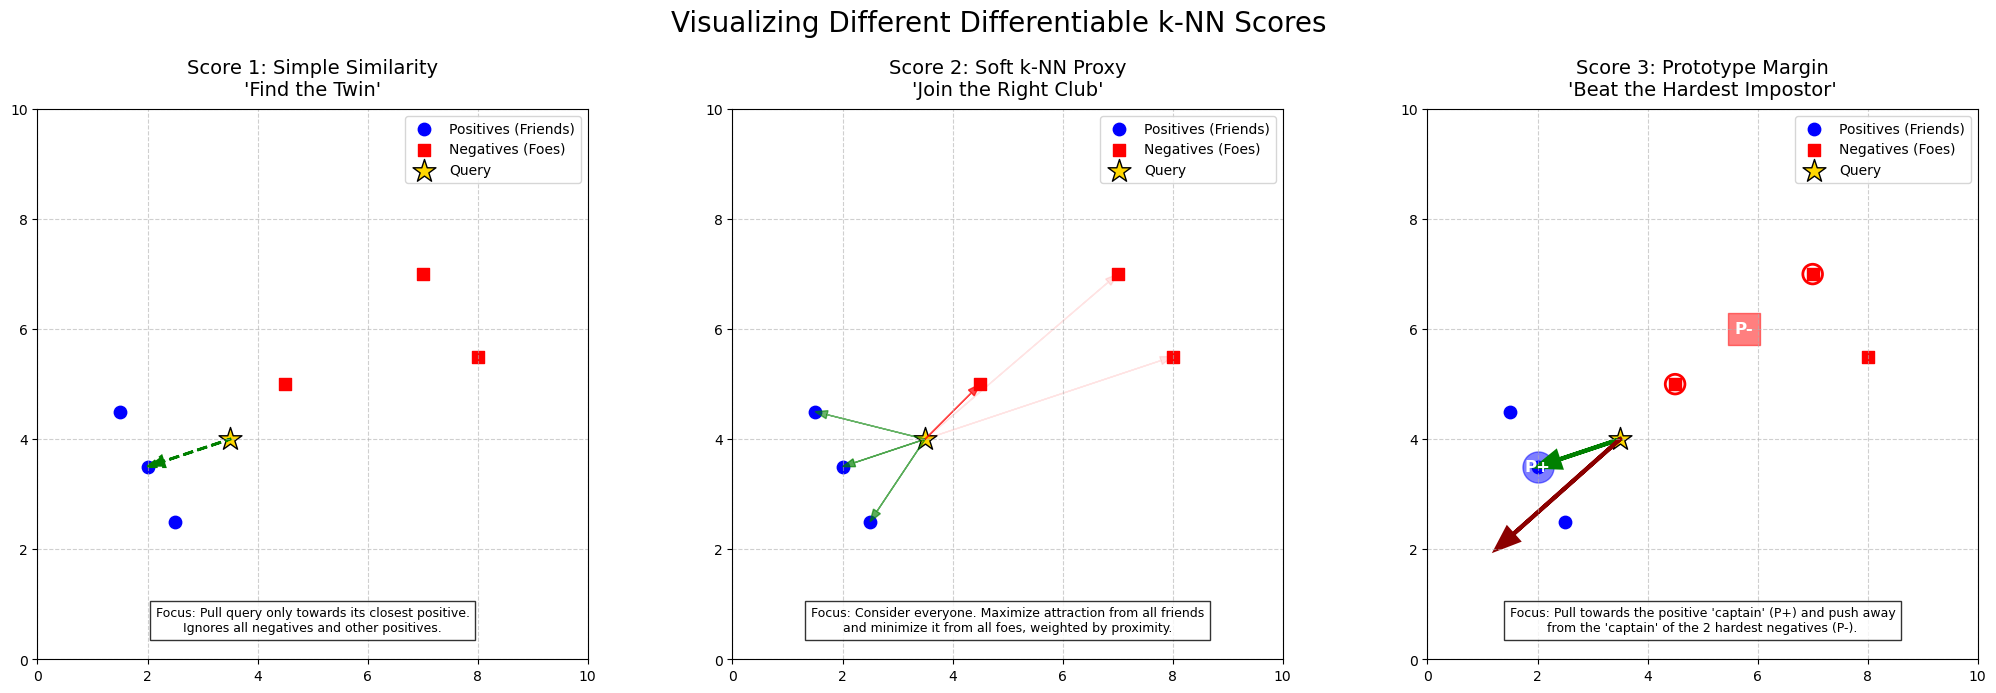

In [ ]:
# --- Create a side-by-side comparison figure ---
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

plot_Similarity Score(axes[0])
plot_knn_proxy_soft(axes[1])
plot_knn_proto_margin(axes[2])

fig.suptitle("Visualizing Different Differentiable k-NN Scores", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

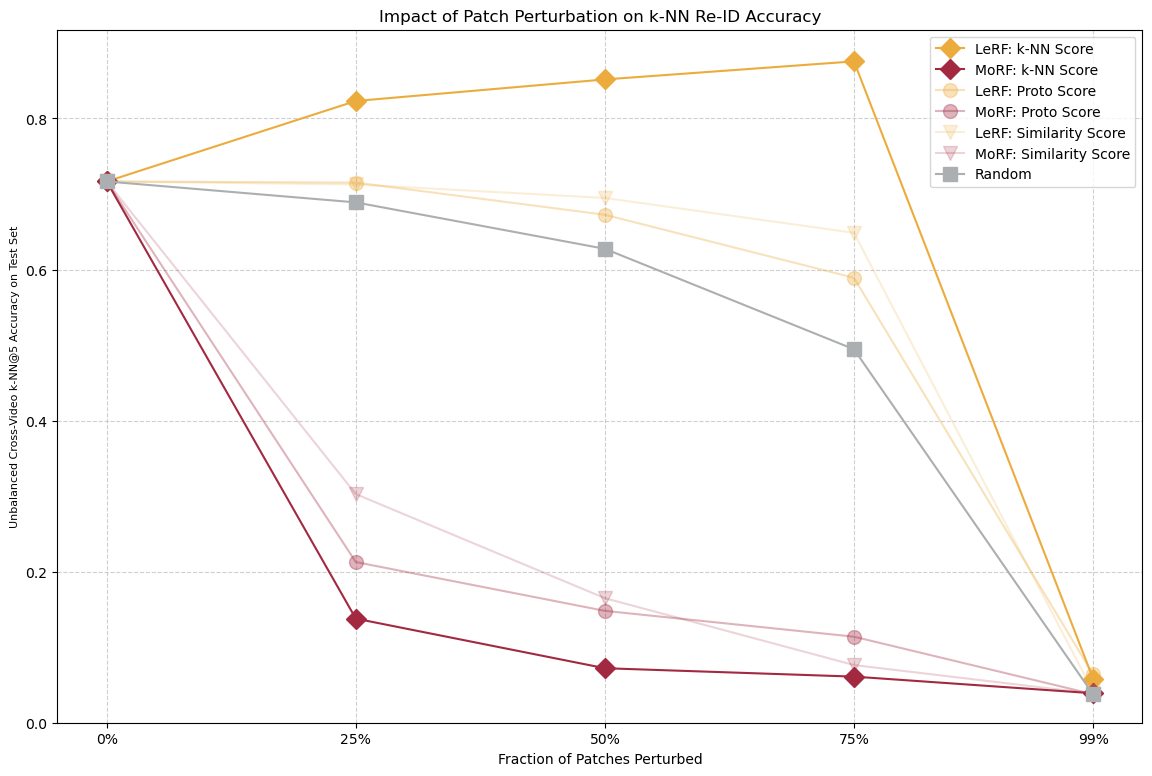

In [ ]:
from collections import defaultdict
from utils import get_hpi_colors, load_config
import matplotlib.pyplot as plt

perturbation_fractions = [0.25, 0.5, 0.75, 0.99]
plot_fractions = [0.0] + perturbation_fractions
DECISION_METRIC = "soft_knn_margin_all"
cfg = load_config("finetuned", [""])
hpi_colors = get_hpi_colors(cfg=cfg)
colors = {
    'MoRF': hpi_colors["red"],
    'LeRF': hpi_colors["yellow"],
    'random': hpi_colors["gray"],
}

transparencies = {
    'Similarity Score': 0.2,
    'k-NN Score': 1,
    'Proto Score': 0.35
}

markers = {
    'Similarity Score': 'v',    # Dreieck nach unten
    'k-NN Score': 'D',    # Diamond
    'Proto Score': 'o'   # Kreis
}
random_marker = 's'

scores  = ['k-NN Score', 'Proto Score','Similarity Score']
results = defaultdict(lambda: defaultdict(list))
results['Similarity Score']['MoRF'] = [0.7165932452276065, 0.302706104468219, 0.16488357457520453, 0.0763582966226138, 0.038598699391650934]
results['Similarity Score']['LeRF'] = [0.7165932452276065, 0.7126075099643382, 0.6947765890497168, 0.6486259702118733, 0.04153555695405916]
results['Similarity Score']['random'] = [0.7165932452276065, 0.6889028739249003, 0.6274386406544997, 0.4944409481854416, 0.03754982169079085]

results['k-NN Score']['MoRF'] = [0.7165932452276065, 0.13782252989301447, 0.07216278581917349, 0.06104468219005664, 0.03901825047199497]
results['k-NN Score']['LeRF'] = [0.7165932452276065, 0.8231592196349906, 0.8516886930983847, 0.8756031046779945, 0.058317600167820435]
results['k-NN Score']['random'] = [0.7165932452276065, 0.6889028739249003, 0.6274386406544997, 0.4944409481854416, 0.03754982169079085]

results['Proto Score']['MoRF'] = [0.7165932452276065, 0.21271239773442416, 0.14810153136144324, 0.11390811831340465, 0.03775959723096287]
results['Proto Score']['LeRF'] = [0.7165932452276065, 0.7151248164464024, 0.6725403817914831, 0.5890497168030208, 0.06398153975246486]
results['Proto Score']['random'] = [0.7165932452276065, 0.6889028739249003, 0.6274386406544997, 0.4944409481854416, 0.03754982169079085]
plt.figure(figsize=(14, 9))


for score in scores:
    for mode in ['LeRF', 'MoRF']:
        plt.plot(plot_fractions, 
                    results[score][mode], 
                    marker=markers[score],
                    markersize=10,
                    linestyle='-', 
                    alpha=transparencies[score],
                    label=mode + ': ' + score, 
                    color=colors.get(mode, 'black')
                )

plt.plot(plot_fractions,
         results['k-NN Score']['random'],
         marker=random_marker,
         markersize=10,
         linestyle='-',
         color=colors['random'],
         label='Random')
finetuned_str = "finetuned" if cfg["model"]["finetuned"] else "base"
plt.title(f'Impact of Patch Perturbation on k-NN Re-ID Accuracy')
plt.xlabel('Fraction of Patches Perturbed')
plt.ylabel(f"Balanced Cross-Encounter k-NN@{cfg['knn']['k']} Accuracy on Queries From Test Set and Database From Train + Test Set", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0)
plt.xticks(plot_fractions, [f'{int(p*100)}%' for p in plot_fractions])

model_name = "finetuned" if cfg["model"]["finetuned"] else "non_finetuned"

save_path = f"knn_perturbation_impact_{model_name}_{DECISION_METRIC}.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()